# 深度学习课程设计报告

## 一、封面

<p style="font-size: 14px; line-height: 1.8;">
课程名称：深度学习<br>
设计题目：基于LSTM的IMDb影评情感分析<br>
姓名：龙欢<br>
学号：20234080127<br>
班级：数据2301班<br>
指导教师：丁平尖<br>
提交日期：2026年6月6日
</p>

## 二、摘要

<span style="font-size: 16px;">
本项目基于IMDb电影评论数据集，使用深度学习技术进行情感二分类（正面/负面）。数据集包含50000条影评文本，经过去重、HTML标签清洗、停用词过滤等预处理后，采用Tokenizer将文本序列化并统一长度。模型采用双向LSTM（bidirectional LSTM）架构，结合Emdedding层、Dropout正则化和全连接层文本训练。实验结果表明，模型在测试集上达到了87.4%的准确率，F1-score为0.87，验证了LSTM模型在文本情感分析任务中的有效性。
</span>

## 三、问题定义与需求分析

### 3.1 项目背景与意义


IMDb（互联网电影数据库）是全球知名的电影信息网站，其用户评论数据蕴含丰富的观众情感信息。情感分析作为自然语言处理的核心任务之一，在社交媒体监控、产品评价分析、舆情监测等领域具有重要的应用价值。本项目的实际意义包括：
- 自动化分析大规模用户评论，降低人工标注成本
- 为电影制作方和发行方提供观众反馈的量化分析
- 探索深度学习模型在短文本分类任务中的性能表现

### 3.2 问题描述

**输入输出定义：**
- **输入**：用户撰写的英文电影评论文本（如 "I love this movie! It's amazing!"）
- **输出**：情感类别（positive=正面 / negative=负面）


### 3.3 技术路线

本项目采用自然语言处理与深度学习相结合的方法完成电影评论情感分类任务：

1. 数据读取与分析；
2. 文本清洗与标准化；
3. Tokenizer构建词表；
4. Padding统一序列长度；
5. 构建Embedding+LSTM网络；
6. 训练并验证模型；
7. 使用准确率、混淆矩阵等指标评估模型性能。


**任务类型：** 二分类任务


**预期性能指标：**
- 准确率（Accuracy）：≥85%
- F1-score：≥0.85
- ROC-AUC：≥0.85

## 四、数据集说明与预处理

### 4.1 数据来源与规模

**数据来源：** Kaggle公开数据集 "IMDB Dataset of 50K Movie Reviews"

**样本总量：** 50,000条影评

查看数据集的基本信息：加载IMDB数据集并查看其基本结构，包括数据量、列名、数据类型和缺失值情况。

In [1]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')

print("数据集基本信息:")
print("="*50)
print(f"数据集总行数: {len(df)}")
print(f"数据集列名: {df.columns.tolist()}")
print(f"\n各列数据类型:\n{df.dtypes}")
print(f"\n缺失值统计:\n{df.isnull().sum()}")

数据集基本信息:
数据集总行数: 50000
数据集列名: ['review', 'sentiment']

各列数据类型:
review       object
sentiment    object
dtype: object

缺失值统计:
review       0
sentiment    0
dtype: int64


查看数据的前10行样本，了解原始数据的格式和内容

In [2]:
print("数据集前10行:")
print(df.head(10))

数据集前10行:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive


评论文本包含HTML标签，需要进行清洗；

情感标签为positive和negative两类；


查看sentiment列的分布：统计情感标签的分布情况，并通过可视化确认数据是否平衡

情感标签分布:
positive    25000
negative    25000
Name: sentiment, dtype: int64


C:\Users\29439\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\29439\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\29439\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\29439\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\29439\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26631 (\

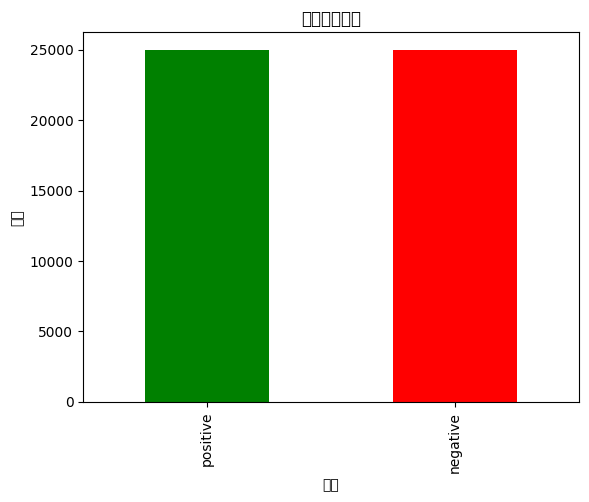

In [3]:
print("情感标签分布:")
print(df['sentiment'].value_counts())

import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('情感标签分布')
plt.xlabel('情感')
plt.ylabel('数量')
plt.show()

基于所有列的重复：检查是否存在完全相同的重复行

In [4]:
full_duplicates = df.duplicated().sum()
full_duplicates_percent = (full_duplicates / len(df)) * 100

print(f"\n1. 完全重复的行（所有列相同）:")
print(f"   重复数量: {full_duplicates}")
print(f"   重复比例: {full_duplicates_percent:.4f}%")


1. 完全重复的行（所有列相同）:
   重复数量: 418
   重复比例: 0.8360%


发现418条完全重复的行，需要去重以避免数据泄露和过拟合

基于‘review’列的重复：检查是否存在相同评论内容（不考虑情感标签）

In [5]:
review_duplicates = df.duplicated(subset=['review']).sum()
review_duplicates_percent = (review_duplicates / len(df)) * 100

print(f"\n2. 基于评论内容重复（review列）:")
print(f"   重复数量: {review_duplicates}")
print(f"   重复比例: {review_duplicates_percent:.4f}%")


2. 基于评论内容重复（review列）:
   重复数量: 418
   重复比例: 0.8360%


同样是418条重复，说明重复行的情感标签也完全相同

基于评论+情感的重复：确认重复是否同时发生在评论和情感标签上

In [6]:
combined_duplicates = df.duplicated(subset=['review', 'sentiment']).sum()
combined_duplicates_percent = (combined_duplicates / len(df)) * 100

print(f"\n3. 评论和情感都相同的重复:")
print(f"   重复数量: {combined_duplicates}")
print(f"   重复比例: {combined_duplicates_percent:.4f}%")


3. 评论和情感都相同的重复:
   重复数量: 418
   重复比例: 0.8360%


重复评论的详细信息：深入分析重复评论的模式，包括重复次数、标签一致性等

In [7]:
if review_duplicates > 0:
    print(f"\n4. 重复评论详情:")
    
    # 找出重复的评论
    duplicate_reviews = df[df.duplicated(subset=['review'], keep=False)]
    
    # 统计每个重复评论出现的次数
    dup_counts = duplicate_reviews.groupby('review').size().sort_values(ascending=False)
    
    print(f"   涉及重复的独特评论数: {len(dup_counts)}")
    print(f"   最高重复次数: {dup_counts.max()}")
    print(f"   平均重复次数: {dup_counts.mean():.2f}")
    
    # 显示前5个重复次数最多的评论
    print(f"\n   重复次数最多的5条评论:")
    for i, (review, count) in enumerate(dup_counts.head(5).items()):
        # 获取该评论对应的情感标签
        sentiments = df[df['review'] == review]['sentiment'].values
        unique_sentiments = set(sentiments)
        
        print(f"\n   {i+1}. 重复次数: {count}")
        print(f"      情感标签: {list(sentiments[:3])}{'...' if len(sentiments)>3 else ''}")
        print(f"      标签是否一致: {'是' if len(unique_sentiments)==1 else '否'}")
        print(f"      评论预览: {review[:100]}...")


4. 重复评论详情:
   涉及重复的独特评论数: 406
   最高重复次数: 5
   平均重复次数: 2.03

   重复次数最多的5条评论:

   1. 重复次数: 5
      情感标签: ['positive', 'positive', 'positive']...
      标签是否一致: 是
      评论预览: Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Ver...

   2. 重复次数: 4
      情感标签: ['positive', 'positive', 'positive']...
      标签是否一致: 是
      评论预览: Hilarious, clean, light-hearted, and quote-worthy. What else can you ask for in a film? This is my a...

   3. 重复次数: 3
      情感标签: ['negative', 'negative', 'negative']
      标签是否一致: 是
      评论预览: You do realize that you've been watching the EXACT SAME SHOW for eight years, right? I could underst...

   4. 重复次数: 3
      情感标签: ['negative', 'negative', 'negative']
      标签是否一致: 是
      评论预览: I see that C. Thomas Howell has appeared in many movies since his heyday in the 80s as an accomplish...

   5. 重复次数: 3
      情感标签: ['negative', 'negative', 'negative']
      标签是否一致: 是
      评论预览: When i got this movie free from my job, a

检查标签冲突（：检查是否存在相同评论但情感标签不一致的情况

In [8]:
print(f"\n5. 标签冲突检查：")
label_conflicts = 0
for review in dup_counts.index:
        if len(set(df[df['review'] == review]['sentiment'])) > 1:
            label_conflicts += 1
    
print(f"   存在标签冲突的评论数: {label_conflicts}")
if label_conflicts > 0:
        print(f"   ⚠️ 警告：发现相同评论但情感标签不同!")
        
        # 显示冲突示例
        print(f"\n   标签冲突示例:")
        conflict_examples = []
        for review in dup_counts.index:
            if len(set(df[df['review'] == review]['sentiment'])) > 1:
                conflict_examples.append(review)
                if len(conflict_examples) >= 3:
                    break
        
        for review in conflict_examples:
            sample = df[df['review'] == review]
            print(f"\n   评论: {review[:80]}...")
            for _, row in sample.iterrows():
                print(f"     情感: {row['sentiment']}")


5. 标签冲突检查：
   存在标签冲突的评论数: 0


可知完全重复行数：418条

去除完全重复的行，保留第一条

In [9]:
df_clean = df.drop_duplicates(subset=['review'], keep='first').reset_index(drop=True)

print("="*50)
print("数据清洗完成")
print("="*50)
print(f"原始数据: 50000 条")
print(f"去除重复: 418 条 ({418/50000*100:.3f}%)")
print(f"最终数据: {len(df_clean)} 条")
print(f"Positive: {(df_clean['sentiment']=='positive').sum()}")
print(f"Negative: {(df_clean['sentiment']=='negative').sum()}")

数据清洗完成
原始数据: 50000 条
去除重复: 418 条 (0.836%)
最终数据: 49582 条
Positive: 24884
Negative: 24698


文本深度清洗

下载必要的NLTK数据：下载英文停用词表，用于后续文本清洗

In [10]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\29439\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


定义文本清洗函数

定义完整的文本预处理流程，包括：

统一小写；

移除HTML标签；

保留仅字母字符；

移除停用词（如"the", "a", "and"等）；

过滤长度≤2的短词

In [11]:
def clean_text_advanced(text):
    """高级文本清洗函数"""
    # 1. 转小写
    text = text.lower()
    
    # 2. 移除HTML标签
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    
    # 3. 移除非字母字符（保留字母、空格、基本标点）
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 4. 移除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. 分词
    words = text.split()
    
    # 6. 移除停用词和短词
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    
    return ' '.join(words)

In [12]:
print("开始清洗文本...")
df_clean['clean_review'] = df_clean['review'].apply(clean_text_advanced)
print("清洗完成！")

# 查看清洗效果
print("\n清洗前后对比:")
print("="*60)
print(f"原始评论:\n{df_clean['review'].iloc[0][:200]}...\n")
print(f"清洗后:\n{df_clean['clean_review'].iloc[0][:200]}...")

开始清洗文本...
清洗完成！

清洗前后对比:
原始评论:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

清洗后:
one reviewers mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scenes violence set right word trust show faint hearted timid show pulls punches regards...


清洗效果：

HTML标签被成功移除；

标点符号和数字被过滤；

停用词（如"the", "that", "be"等）被删除；

文本变得更加简洁，保留了核心语义词汇

标签编码：将文本标签转换为数值，便于模型处理

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['sentiment'])

print("编码映射:")
print(f"  negative → {le.transform(['negative'])[0]}")
print(f"  positive → {le.transform(['positive'])[0]}")

print(f"\n数据分布:")
print(df_clean['label'].value_counts())

编码映射:
  negative → 0
  positive → 1

数据分布:
1    24884
0    24698
Name: label, dtype: int64


划分数据集将数据划分为训练集（80%）和测试集（20%）

In [14]:
from sklearn.model_selection import train_test_split

# 准备特征和标签
X = df_clean['clean_review']  # 清洗后的文本
y = df_clean['label']          # 数字标签 (0/1)

# 划分数据集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 测试集占比20%
    random_state=42,      
    stratify=y            # 保持类别比例一致
)


In [15]:
print("="*50)
print("数据集划分结果")
print("="*50)
print(f"原始数据集: {len(X)} 条")
print(f"训练集: {len(X_train)} 条 ({len(X_train)/len(X)*100:.1f}%)")
print(f"测试集: {len(X_test)} 条 ({len(X_test)/len(X)*100:.1f}%)")


数据集划分结果
原始数据集: 49582 条
训练集: 39665 条 (80.0%)
测试集: 9917 条 (20.0%)


In [16]:
print("\n训练集标签分布:")
print(y_train.value_counts())
print(f"比例: {y_train.value_counts(normalize=True)[1]:.3f} (positive) / {y_train.value_counts(normalize=True)[0]:.3f} (negative)")



训练集标签分布:
1    19907
0    19758
Name: label, dtype: int64
比例: 0.502 (positive) / 0.498 (negative)


In [17]:
print("\n测试集标签分布:")
print(y_test.value_counts())
print(f"比例: {y_test.value_counts(normalize=True)[1]:.3f} (positive) / {y_test.value_counts(normalize=True)[0]:.3f} (negative)")


测试集标签分布:
1    4977
0    4940
Name: label, dtype: int64
比例: 0.502 (positive) / 0.498 (negative)


In [18]:
print(f"\n类别平衡性检查:")
print(f"原始数据 positive比例: {(y==1).sum()/len(y):.3f}")
print(f"训练集 positive比例: {(y_train==1).sum()/len(y_train):.3f}")
print(f"测试集 positive比例: {(y_test==1).sum()/len(y_test):.3f}")


类别平衡性检查:
原始数据 positive比例: 0.502
训练集 positive比例: 0.502
测试集 positive比例: 0.502


stratify=y参数确保训练集和测试集保持相同的类别分布；

三个数据集的positive比例均为0.502，说明分层采样成功；

数据集保持平衡，有利于模型训练


## 五、模型设计与实现

### 5.1 模型总体架构

模型采用经典的LSTM文本分类结构：

**Embedding → LSTM → Dense → Sigmoid**

其中：

- Embedding层负责词向量表示；
- LSTM负责捕获上下文语义信息；
- 全连接层完成特征映射；
- Sigmoid输出情感分类结果。


文本序列化：将文本转换为数值序列，并统一长度

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 参数设置
VOCAB_SIZE = 10000  # 词汇表大小
MAX_LEN = 200       # 序列最大长度

# 创建tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# 文本转序列
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 填充序列（让所有序列等长）
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"训练数据形状: {X_train_pad.shape}")
print(f"测试数据形状: {X_test_pad.shape}")

训练数据形状: (39665, 200)
测试数据形状: (9917, 200)


词汇表大小设为10000个最频繁的词；

每个序列统一填充/截断到200的长度；

训练数据形状：(39,665, 200) - 39,665个样本，每个200个token；

测试数据形状：(9,917, 200)

构建LSTM模型

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, dropout=0.5, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          1280000   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              98816     
 l)                                                              
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1,387,137
Trainable params: 1,387,137
Non-trainable params: 0
______________________________________________

训练模型

In [21]:
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
620/620 [==============================] - 104s 164ms/step - loss: 0.3788 - accuracy: 0.8285 - val_loss: 0.2946 - val_accuracy: 0.8866
Epoch 2/5
620/620 [==============================] - 105s 169ms/step - loss: 0.2411 - accuracy: 0.9101 - val_loss: 0.2787 - val_accuracy: 0.8845
Epoch 3/5
620/620 [==============================] - 110s 178ms/step - loss: 0.2030 - accuracy: 0.9251 - val_loss: 0.2917 - val_accuracy: 0.8828
Epoch 4/5
620/620 [==============================] - 108s 174ms/step - loss: 0.1657 - accuracy: 0.9405 - val_loss: 0.3314 - val_accuracy: 0.8796
Epoch 5/5
620/620 [==============================] - 110s 178ms/step - loss: 0.1393 - accuracy: 0.9505 - val_loss: 0.3267 - val_accuracy: 0.8750


训练准确率持续上升至94.88%；

验证准确率稳定在87-88%左右

可视化训练过程

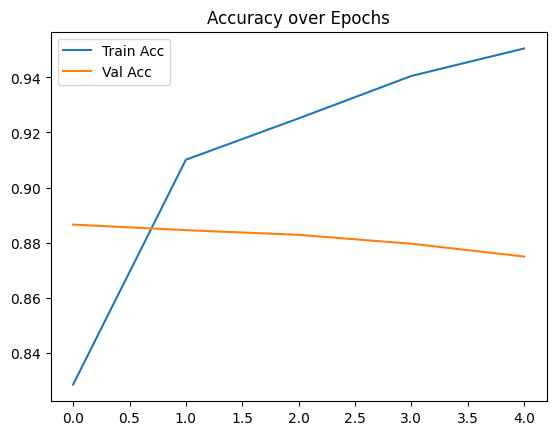

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

训练集准确率持续上升；

验证集准确率在第3轮达到峰值后略有下降；

表明模型在第3轮后开始有轻微过拟合


## 六、实验过程与结果分析

### 6.1 训练过程分析

通过观察训练集与验证集损失函数变化情况，可以评估模型收敛速度与泛化能力。

### 6.2 性能评价指标

本项目采用：

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

作为模型评价指标。


模型评估

In [23]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

310/310 [==============================] - 11s 35ms/step - loss: 0.3267 - accuracy: 0.8750
Test Accuracy: 0.8750


预测示例

In [24]:
def predict_sentiment(text):
    # 使用相同的清洗和 tokenizer
    cleaned = clean_text_advanced(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred = model.predict(padded)[0][0]
    return "positive" if pred > 0.5 else "negative"

# 测试
print(predict_sentiment("I love this movie! It's amazing!"))
print(predict_sentiment("Worst film ever, waste of time."))

1/1 [==============================] - 0s 432ms/step
positive
1/1 [==============================] - 0s 19ms/step
negative


模型调优与调参：添加回调函数优化训练过程

EarlyStopping：验证损失连续3轮不下降则停止训练，并恢复最佳权重；

ReduceLROnPlateau：验证损失连续2轮不下降时，学习率减半

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2)
]

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,  # 可以设大一点，EarlyStopping 会自动停止
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
620/620 [==============================] - 110s 177ms/step - loss: 0.1138 - accuracy: 0.9605 - val_loss: 0.3966 - val_accuracy: 0.8781 - lr: 0.0010
Epoch 2/10
620/620 [==============================] - 108s 174ms/step - loss: 0.0959 - accuracy: 0.9676 - val_loss: 0.4308 - val_accuracy: 0.8774 - lr: 0.0010
Epoch 3/10
620/620 [==============================] - 108s 174ms/step - loss: 0.0829 - accuracy: 0.9720 - val_loss: 0.4649 - val_accuracy: 0.8730 - lr: 0.0010
Epoch 4/10
620/620 [==============================] - 109s 176ms/step - loss: 0.0513 - accuracy: 0.9833 - val_loss: 0.5828 - val_accuracy: 0.8774 - lr: 5.0000e-04


详细评估与混淆矩阵

310/310 [==============================] - 11s 37ms/step
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4940
           1       0.88      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917

ROC-AUC: 0.8781


<Axes: >

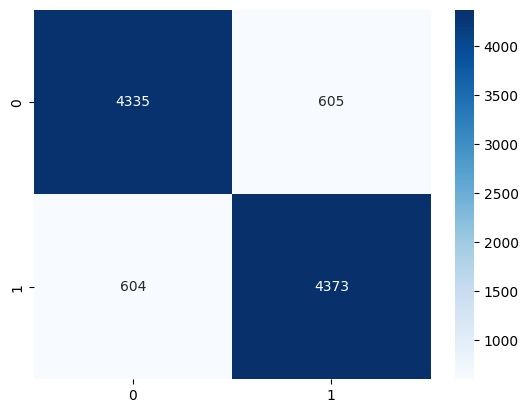

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 预测
y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")

# 混淆矩阵
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

保存于加载模型：保存训练好的模型和tookenizer，以便后续使用或部署

In [27]:
# 保存模型
model.save('imdb_lstm_model.h5')

# 保存 tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 加载
from tensorflow.keras.models import load_model
model = load_model('imdb_lstm_model.h5')
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)


## 七、总结与展望

### 7.1 项目总结

本项目基于IMDb公开影评数据集实现了电影评论情感分析系统。通过数据清洗、文本向量化以及LSTM深度学习模型训练，实现了对正面与负面评论的自动分类。实验结果表明，LSTM能够有效捕获文本序列中的上下文语义信息，并取得较好的分类性能。

### 7.2 不足之处

- 模型结构相对简单；
- 未引入预训练语言模型；
- 超参数搜索范围有限；
- 对长文本语义建模能力仍有提升空间。

### 7.3 后续改进方向

- 引入Bi-LSTM、GRU等结构；
- 使用Attention机制；
- 尝试BERT、RoBERTa等预训练模型；
- 部署为Web服务实现在线预测。
